# Stationary FPT and FAPT for smooth time-dependent controls

This notebook separates the effects of the three time-dependent control parameters. Starting from the same constant reference, only one quantity is varied in each test:

1. $A_r(t)$ only;
2. $A_i(t)$ only;
3. $\omega_d(t)$ only.

Part I compares stationary FPT with the full 27-dimensional dynamics. Part II repeats exactly the same comparison with all FAPT corrections enabled. Only the initial state $|a\rangle$ is propagated.

## Configuration: strength and timescale of the pulse variation

In [ ]:
from pathlib import Path

import numpy as np
import qutip as qt
import scipy.linalg as scipy_linalg
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from tqdm.auto import tqdm

from Floquet_perturbation_theory import *
from FAPT import *
from helper_function import *
from utils import *

def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 11.5,
        "font.size": 11,
        "legend.fontsize": 9.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 12,
        "axes.titlesize": 11.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 5.0,
    })

s = Simulation()
tg = 180.0
N_t = 601
rH = 3
rW = 2
tlist = np.linspace(0.0, tg, N_t)
x = tlist / tg

# Main controls for the severity of the time dependence.
time_dependence_strength = 1.0   # Multiplies every excursion below.
width_fraction = 0.22            # Gaussian width / tg; smaller means faster variation.
oscillation_cycles = 0           # Smooth Ar/Ai oscillations over the full gate.
use_monotonic_ramp = False       # True: replace Ar/Ai oscillations by a linear rise from t=0 to tg.

# Hard amplitude caps; increasing oscillation_cycles does not change them.
Ar_excursion = 1              # Ar is restricted to A0*(1 +- Ar_excursion).
Ai_excursion = 1              # Ai is restricted to +-Ai_excursion*A0.
wd_excursion = 0.05             # Maximum |wd-wd0| in rad/ns.

FAPT_TERMS = {
    "include_geometric": True,
    "include_micromotion": True,
    "include_g_correction": True,
}

state_a, state_b = s.state_a, s.state_b
res_indices = list(s.resonances)
idx_a, idx_b = res_indices.index(state_a), res_indices.index(state_b)
wd0, A0 = compute_cos_params(s, tg)

plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.labelsize": 10, "axes.titlesize": 10, "legend.fontsize": 8.0, "xtick.labelsize": 9, "ytick.labelsize": 9})
Path("Figure").mkdir(exist_ok=True)

profile_mode = "monotonic linear ramp" if use_monotonic_ramp else "Gaussian-windowed oscillations"
print(f"A0={A0:.6g}, wd0={wd0:.6g}, strength={time_dependence_strength}, width/tg={width_fraction}, Ar/Ai mode={profile_mode}")

A0=0.984159, wd0=4.44674, strength=1.0, width/tg=0.22, Ar/Ai mode=Gaussian-windowed oscillations


## One-parameter-at-a-time pulse family

The four columns used below are a constant reference and three isolated variations. By default, $A_r(t)$ and $A_i(t)$ contain a small number of smooth oscillations inside a Gaussian envelope. With `use_monotonic_ramp=True`, both are instead generated from a linearly increasing profile that never falls during the gate and therefore has constant sign of the first derivative. Their absolute scales remain hard-capped in both modes. The frequency-only case retains the single smooth Gaussian variation. Consequently, any discrepancy can be assigned directly to $\dot A_r$, $\dot A_i$, or $\dot\omega_d$.

In [2]:
def normalized(values):
    scale = np.max(np.abs(values))
    return values / scale if scale > 0 else np.zeros_like(values)


# Normiertes Gauß-Fenster (0 an den Rändern t=0 und t=tg, 1 in der Mitte)
gaussian = np.exp(-0.5 * ((x - 0.5) / width_fraction) ** 2)
profile = (gaussian - gaussian[0]) / (np.max(gaussian) - gaussian[0])

# Standard-Konstanten für die nicht-variierenden Anteile in den modulieren Pulsen
constant_Ar = np.full_like(tlist, A0)
constant_Ai = np.zeros_like(tlist)
constant_wd = np.full_like(tlist, wd0)

# Zeitabhängige Steuerungen (Gauß-Profile)
Ar_varying = np.clip(
    A0 * (1.0 + time_dependence_strength * Ar_excursion * profile),
    A0 * (1.0 - Ar_excursion),
    A0 * (1.0 + Ar_excursion),
)

Ai_varying = np.clip(
    time_dependence_strength * Ai_excursion * A0 * profile,
    -Ai_excursion * A0,
    Ai_excursion * A0,
)

wd_varying = wd0 + time_dependence_strength * wd_excursion * profile

# Konstante Verläufe speziell für die "Constant reference" (auf Maximalwerte gesetzt)
constant_Ar_max = np.full_like(tlist, np.max(Ar_varying))
constant_Ai_max = np.full_like(tlist, np.max(np.abs(Ai_varying)))

pulses = {
    "Constant reference": {
        "Ar": constant_Ar_max.copy(),
        "Ai": constant_Ai_max.copy(),
        "wd": constant_wd.copy(),
    },
    "Only Ar(t)": {
        "Ar": Ar_varying,
        "Ai": constant_Ai.copy(),  # Bleibt exakt 0
        "wd": constant_wd.copy(),
    },
    "Only Ai(t)": {
        "Ar": constant_Ar.copy(),  # Bleibt exakt A0
        "Ai": Ai_varying,
        "wd": constant_wd.copy(),
    },
    "Only wd(t)": {
        "Ar": constant_Ar.copy(),  # Bleibt exakt A0
        "Ai": constant_Ai.copy(),  # Bleibt exakt 0
        "wd": wd_varying,
    },
}

for name, pulse in pulses.items():
    dA = np.gradient(pulse["Ar"] + 1j * pulse["Ai"], tlist)
    dwd = np.gradient(pulse["wd"], tlist)
    print(
        f"{name:20s}: Ar/A0=[{pulse['Ar'].min()/A0:.3f},"
        f" {pulse['Ar'].max()/A0:.3f}],"
        f" max|Ai|/A0={np.max(np.abs(pulse['Ai']))/A0:.3f},"
        f" max|dA|={np.max(np.abs(dA)):.3e},"
        f" max|dwd|={np.max(np.abs(dwd)):.3e},"
        f" max|t dwd|={np.max(np.abs(tlist*dwd)):.3e}"
    )

Constant reference  : Ar/A0=[2.000, 2.000], max|Ai|/A0=1.000, max|dA|=0.000e+00, max|dwd|=0.000e+00, max|t dwd|=0.000e+00
Only Ar(t)          : Ar/A0=[1.000, 2.000], max|Ai|/A0=0.000, max|dA|=1.957e-02, max|dwd|=0.000e+00, max|t dwd|=0.000e+00
Only Ai(t)          : Ar/A0=[1.000, 1.000], max|Ai|/A0=1.000, max|dA|=1.957e-02, max|dwd|=0.000e+00, max|t dwd|=0.000e+00
Only wd(t)          : Ar/A0=[1.000, 1.000], max|Ai|/A0=0.000, max|dA|=0.000e+00, max|dwd|=9.941e-04, max|t dwd|=1.099e-01


## Shared numerical propagation routines

In [3]:
def frame_map(wd, W, time):
    D, d_res, kref = len(s.E_array), len(s.resonances), min(s.resonances)
    M = np.zeros((D, d_res), dtype=complex)
    for order in range(rW + 1):
        for l in range(D):
            for column, state in enumerate(s.resonances):
                for p, (coefficient, _, _) in W[order, l, state].items():
                    M[l, column] += np.exp(-1j * (s.E_array[kref] + p * wd) * time) * coefficient
    return M


def compute_W_grid(pulse, name):
    if np.allclose(pulse["Ar"], pulse["Ar"][0]) and np.allclose(pulse["Ai"], pulse["Ai"][0]) and np.allclose(pulse["wd"], pulse["wd"][0]):
        A = pulse["Ar"][0] + 1j * pulse["Ai"][0]
        W = W_Floquet_elements_fast(rW, pulse["wd"][0], s.resonances, s.E_array, s.V1_dressed_array, A=A, V0=None, analytics=False, verbose=False)
        return [W] * len(tlist)

    W_values = []
    for k in tqdm(range(len(tlist)), desc=f"W: {name}"):
        A = pulse["Ar"][k] + 1j * pulse["Ai"][k]
        W_values.append(W_Floquet_elements_fast(rW, pulse["wd"][k], s.resonances, s.E_array, s.V1_dressed_array, A=A, V0=None, analytics=False, verbose=False))
    return W_values


def compute_H_grid(pulse, W_values, include_fapt, name):
    d_res = len(s.resonances)
    A_values = pulse["Ar"] + 1j * pulse["Ai"]
    dA_values = np.gradient(A_values, tlist)
    dwd_values = np.gradient(pulse["wd"], tlist)
    H_values = np.empty((len(tlist), d_res, d_res), dtype=complex)

    for k in tqdm(range(len(tlist)), desc=f"{'FAPT' if include_fapt else 'FPT'} H_eff: {name}"):
        H = Heff_Floquet_total_matrix_summed(rH, pulse["wd"][k], A_values[k], s.resonances, s.E_array, s.V1_dressed_array, V0=None, ref_state=None, dwd=dwd_values[k] if include_fapt else 0.0, dA=dA_values[k] if include_fapt else 0.0, t=tlist[k], analytics=False, rW=rW, include_geometric=FAPT_TERMS["include_geometric"] if include_fapt else False, include_micromotion=FAPT_TERMS["include_micromotion"] if include_fapt else False, include_g_correction=FAPT_TERMS["include_g_correction"] if include_fapt else False, W=W_values[k], verbose=False)
        H_values[k] = np.asarray(H, dtype=complex)
    return H_values


def propagate_theory(pulse, W_values, H_values):
    d_res = len(s.resonances)
    H_spline = CubicSpline(tlist, H_values, axis=0)
    M_inv_0 = frame_map(pulse["wd"][0], W_values[0], 0.0).conj().T
    phi_a = M_inv_0[:, state_a]
    U_eff = np.eye(d_res, dtype=complex)
    amplitudes = np.empty((len(tlist), d_res), dtype=complex)

    for k, time in enumerate(tlist):
        psi = frame_map(pulse["wd"][k], W_values[k], time) @ U_eff @ phi_a
        psi /= np.linalg.norm(psi)
        amplitudes[k] = psi[res_indices]
        if k < len(tlist) - 1:
            dt = tlist[k + 1] - tlist[k]
            U_eff = scipy_linalg.expm(-1j * H_spline(0.5 * (tlist[k] + tlist[k + 1])) * dt) @ U_eff
    return amplitudes


def compute_direct_trajectory(pulse):
    Ar = CubicSpline(tlist, pulse["Ar"])
    Ai = CubicSpline(tlist, pulse["Ai"])
    wd = CubicSpline(tlist, pulse["wd"])
    q = lambda time, args=None: float(np.real_if_close(Ar(time) * np.cos(wd(time) * time) + Ai(time) * np.sin(wd(time) * time)))
    result = qt.sesolve([s.H0, [s.V1, q]], s.E_states[state_a], tlist)
    return np.asarray([[s.E_states[state].overlap(psi) for state in res_indices] for psi in result.states], dtype=complex)

## Shared Floquet transformations and direct reference

$W(t)$ and the direct 27-dimensional trajectories are calculated once and reused in both theory comparisons. This guarantees that Part I and Part II differ only through the adiabatic correction added to $H_{\mathrm{eff}}$.

In [4]:
prepared = {}

for name, pulse in pulses.items():
    print(f"Preparing {name} ...")
    prepared[name] = {
        "W": compute_W_grid(pulse, name),
        "direct": compute_direct_trajectory(pulse),
    }

Preparing Constant reference ...
Preparing Only Ar(t) ...


W: Only Ar(t): 100%|██████████| 601/601 [01:01<00:00,  9.74it/s]


Preparing Only Ai(t) ...


W: Only Ai(t): 100%|██████████| 601/601 [01:02<00:00,  9.65it/s]


Preparing Only wd(t) ...


W: Only wd(t): 100%|██████████| 601/601 [01:01<00:00,  9.71it/s]


# Part I: stationary FPT

All derivatives and all FAPT correction terms are set to zero. The four columns isolate the failure associated with each time-dependent control.

In [5]:
fpt_results = {}

for name, pulse in pulses.items():
    H_fpt = compute_H_grid(pulse, prepared[name]["W"], include_fapt=False, name=name)
    fpt_results[name] = propagate_theory(pulse, prepared[name]["W"], H_fpt)

FPT H_eff: Only wd(t): 100%|██████████| 601/601 [00:39<00:00, 15.04it/s]


## Stationary-FPT comparison

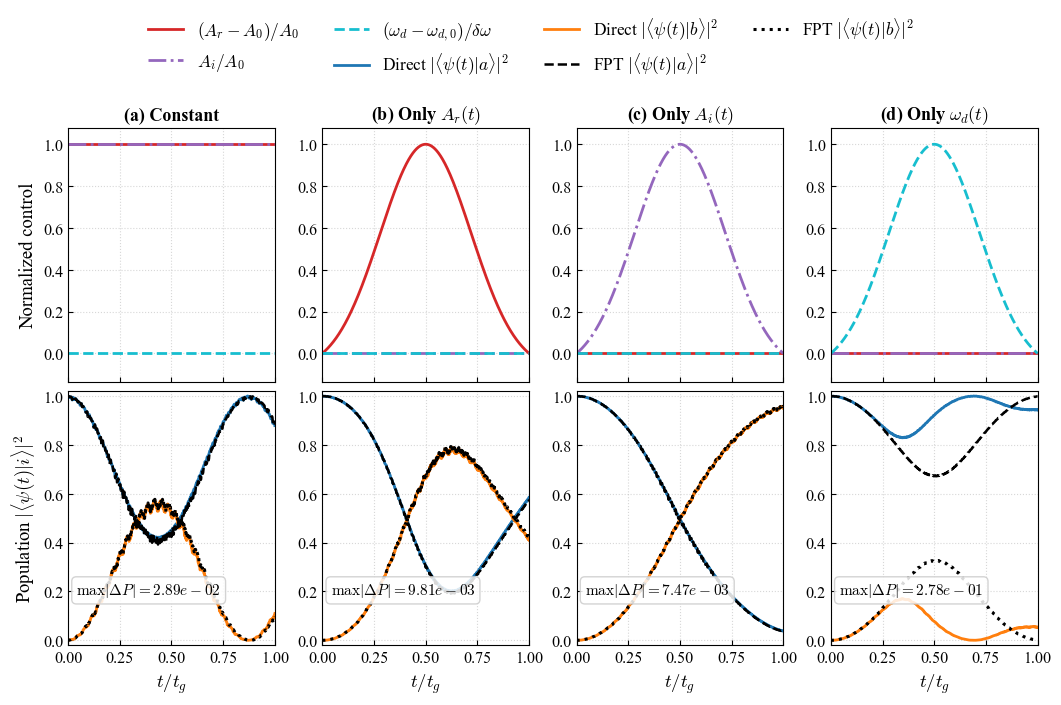

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_comparison(theory_results, theory_label, savepath):
    setup_paper_style()

    titles = [
        "(a) Constant",
        r"(b) Only $A_r(t)$",
        r"(c) Only $A_i(t)$",
        r"(d) Only $\omega_d(t)$",
    ]

    # Farben
    c_Ar = "#d62728"  # Rot/Karmesin (Realteil)
    c_Ai = "#9467bd"  # Violett (Imaginärteil)
    c_wd = "#17becf"  # Cyan/Türkis (Drive-Frequenz)
    c_a = "#1f77b4"  # Blau (State a)
    c_b = "#ff7f0e"  # Orange (State b)
    c_theory = "#000000"  # Schwarz für FPT-Theorie

    # Erhöhte Schriftgrößen für Paper-Layout
    plot_style = {
        "axes.labelsize": 13.5,
        "axes.titlesize": 13.0,
        "xtick.labelsize": 11.5,
        "ytick.labelsize": 11.5,
        "legend.fontsize": 12.5,  # Vergrößerte Legendenschrift
        "lines.linewidth": 2.0,
    }

    normalized_controls = []
    for pulse in pulses.values():
        normalized_controls.extend(
            [
                (pulse["Ar"] - A0) / A0,
                pulse["Ai"] / A0,
                (pulse["wd"] - wd0) / wd_excursion,
            ]
        )
    control_max = max(np.max(np.abs(values)) for values in normalized_controls)
    if control_max == 0:
        control_max = 1.0

    with plt.rc_context(plot_style):
        fig, axes = plt.subplots(
            2, 4, figsize=(10.5, 6.0), sharex="col", constrained_layout=True
        )

        for column, ((name, pulse), title) in enumerate(
            zip(pulses.items(), titles)
        ):
            direct = prepared[name]["direct"]
            theory = theory_results[name]

            direct_a = np.abs(direct[:, idx_a]) ** 2
            direct_b = np.abs(direct[:, idx_b]) ** 2
            theory_a = np.abs(theory[:, idx_a]) ** 2
            theory_b = np.abs(theory[:, idx_b]) ** 2

            deviation = max(
                np.max(np.abs(direct_a - theory_a)),
                np.max(np.abs(direct_b - theory_b)),
            )

            # Top panel: Controls (Ar um A0 bereinigt, startet bei 0)
            axes[0, column].plot(
                x,
                (pulse["Ar"] - A0) / A0,
                "-",
                color=c_Ar,
                label=r"$(A_r-A_0)/A_0$",
            )
            axes[0, column].plot(
                x, pulse["Ai"] / A0, "-.", color=c_Ai, label=r"$A_i/A_0$"
            )
            axes[0, column].plot(
                x,
                (pulse["wd"] - wd0) / wd_excursion,
                "--",
                color=c_wd,
                label=r"$(\omega_d-\omega_{d,0})/\delta\omega$",
            )
            axes[0, column].set_title(title, fontweight="bold")
            axes[0, column].set_ylim(-1.08/8 * control_max, 1.08 * control_max)

            # Bottom panel: Dynamics (Mathematisch korrekte Projektionsnotations)
            axes[1, column].plot(
                x,
                direct_a,
                "-",
                color=c_a,
                lw=2.0,
                label=r"Direct $|\langle\psi(t)|a\rangle|^2$",
            )
            axes[1, column].plot(
                x,
                direct_b,
                "-",
                color=c_b,
                lw=2.0,
                label=r"Direct $|\langle\psi(t)|b\rangle|^2$",
            )
            axes[1, column].plot(
                x,
                theory_a,
                "--",
                color=c_theory,
                lw=1.8,
                alpha=1.0,
                zorder=5,
                label=rf"{theory_label} $|\langle\psi(t)|a\rangle|^2$",
            )
            axes[1, column].plot(
                x,
                theory_b,
                ":",
                color=c_theory,
                lw=2.2,
                alpha=1.0,
                zorder=5,
                label=rf"{theory_label} $|\langle\psi(t)|b\rangle|^2$",
            )

            # Textbox mit weißem Hintergrund
            axes[1, column].text(
                0.04,
                0.2,
                rf"$\max|\Delta P|={deviation:.2e}$",
                transform=axes[1, column].transAxes,
                fontsize=11.0,
                zorder=6,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    edgecolor="0.8",
                    alpha=0.85,
                ),
            )
            axes[1, column].set_xlabel(r"$t/t_g$")
            axes[1, column].set_xlim(0.0, 1.0)
            axes[1, column].set_ylim(-0.02, 1.02)

            for row in range(2):
                axes[row, column].grid(
                    True,
                    which="both",
                    linestyle=":",
                    alpha=0.5,
                    linewidth=0.8,
                )
                axes[row, column].tick_params(direction="in", labelsize=11.5)

        axes[0, 0].set_ylabel("Normalized control")
        axes[1, 0].set_ylabel(r"Population $|\langle\psi(t)|i\rangle|^2$")

        # Globale Legende über den Subplots
        control_handles, control_labels = (
            axes[0, 0].get_legend_handles_labels()
        )
        dynamics_handles, dynamics_labels = (
            axes[1, 0].get_legend_handles_labels()
        )

        fig.legend(
            control_handles + dynamics_handles,
            control_labels + dynamics_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.01),
            ncol=4,
            frameon=False,
            fontsize=12.5,
        )

        output_file = Path(savepath)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_file, dpi=600, bbox_inches="tight")
        plt.show()

    return fig, axes


fig, axes = plot_comparison(
    fpt_results, "FPT", "Figure/fpt_isolated_time_dependence.pdf"
)

# Part II: FAPT-corrected dynamics

The same $W(t)$, pulse arrays, initial state, and direct simulations are retained. The only change is that $\dot A$ and $\dot\omega_d$ are supplied to `Heff_Floquet_total_matrix_summed` and the selected FAPT terms are enabled.

In [7]:
fapt_results = {}

for name, pulse in pulses.items():
    H_fapt = compute_H_grid(pulse, prepared[name]["W"], include_fapt=True, name=name)
    fapt_results[name] = propagate_theory(pulse, prepared[name]["W"], H_fapt)

FAPT H_eff: Only wd(t): 100%|██████████| 601/601 [00:42<00:00, 14.20it/s]


## FAPT comparison

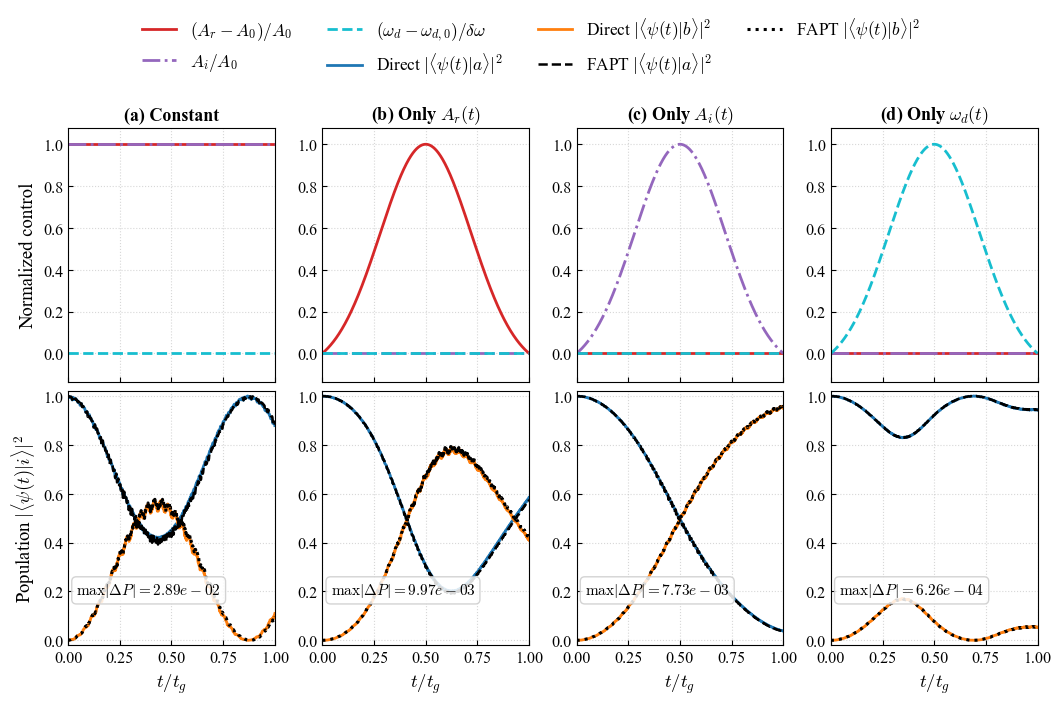

(<Figure size 1050x600 with 8 Axes>,
 array([[<Axes: title={'center': '(a) Constant'}, ylabel='Normalized control'>,
         <Axes: title={'center': '(b) Only $A_r(t)$'}>,
         <Axes: title={'center': '(c) Only $A_i(t)$'}>,
         <Axes: title={'center': '(d) Only $\\omega_d(t)$'}>],
        [<Axes: xlabel='$t/t_g$', ylabel='Population $|\\langle\\psi(t)|i\\rangle|^2$'>,
         <Axes: xlabel='$t/t_g$'>, <Axes: xlabel='$t/t_g$'>,
         <Axes: xlabel='$t/t_g$'>]], dtype=object))

In [8]:
plot_comparison(fapt_results, "FAPT", "Figure/fapt_isolated_time_dependence.pdf")

## Interpretation

The first figure identifies which individual parameter variation causes stationary FPT to deviate from the direct dynamics. The second figure tests whether the adiabatic corrections restore agreement for the same smooth pulses. The frequency-only column is particularly diagnostic: in the phase convention $\omega_d(t)t$, the physical phase velocity contains $\omega_d+t\dot\omega_d$, so even a moderate frequency excursion can require the micromotion correction.

The $A_r$ and $A_i$ amplitudes remain bounded in both available profile modes. With `use_monotonic_ramp=False`, increase `oscillation_cycles` moderately to enlarge $|\dot A|$ without increasing the perturbative drive scale; values around 3--6 remain smooth on the scale of a $200\,\mathrm{ns}$ gate. With `use_monotonic_ramp=True`, the controls rise linearly throughout the gate and never return, providing a direct test of corrections that are linear in $\dot A$. `width_fraction` controls the Gaussian envelope used by the oscillatory and frequency-only tests, whereas `time_dependence_strength` reduces the excursions below their hard caps. The frequency-only test remains controlled independently by `wd_excursion`.